## <font size=5> <strong>Heart Disease Prediction By Javvaji Bhuvi
 

## I. Importing essential libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import os
print(os.listdir())

import warnings
warnings.filterwarnings('ignore')

['.ipynb_checkpoints', 'heart.csv', 'Heart_disease_prediction.ipynb']


## II. Importing and understanding our dataset 

In [5]:
dataset = pd.read_csv("heart.csv")

#### Verifying it as a 'dataframe' object in pandas

In [6]:
type(dataset)

pandas.core.frame.DataFrame

#### Shape of dataset

In [7]:
dataset.shape

(918, 12)

#### Printing out a few columns

In [8]:
dataset.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [9]:
dataset.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
141,50,M,ASY,140,341,0,ST,125,Y,2.5,Flat,1
501,63,M,ASY,130,308,0,Normal,138,Y,2.0,Flat,1
263,59,M,ASY,130,126,0,Normal,125,N,0.0,Flat,1
243,43,F,ATA,120,266,0,Normal,118,N,0.0,Up,0
814,77,M,ASY,125,304,0,LVH,162,Y,0.0,Up,1


#### Description

In [10]:
dataset.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [12]:
###Luckily, we have no missing values

#### Let's understand our columns better:

In [13]:
info = [
    "Age of the patient",
    "Gender (1: Male, 0: Female)",
    "Type of chest pain",
    "Resting blood pressure (mm Hg)",
    "Serum cholesterol in mg/dl",
    "Fasting blood sugar > 120 mg/dl (1 = True, 0 = False)",
    "Resting electrocardiographic results",
    "Maximum heart rate achieved",
    "Exercise-induced angina (1 = Yes, 0 = No)",
    "ST depression induced by exercise relative to rest",
    "Slope of the peak exercise ST segment",
    "Heart disease presence (1 = Yes, 0 = No)"
]
for col, desc in zip(dataset.columns, info):
    print(col + " :\t\t" + desc)

Age :		Age of the patient
Sex :		Gender (1: Male, 0: Female)
ChestPainType :		Type of chest pain
RestingBP :		Resting blood pressure (mm Hg)
Cholesterol :		Serum cholesterol in mg/dl
FastingBS :		Fasting blood sugar > 120 mg/dl (1 = True, 0 = False)
RestingECG :		Resting electrocardiographic results
MaxHR :		Maximum heart rate achieved
ExerciseAngina :		Exercise-induced angina (1 = Yes, 0 = No)
Oldpeak :		ST depression induced by exercise relative to rest
ST_Slope :		Slope of the peak exercise ST segment
HeartDisease :		Heart disease presence (1 = Yes, 0 = No)


#### Analysing the 'target' variable

In [14]:
dataset["HeartDisease"].describe()

count    918.000000
mean       0.553377
std        0.497414
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: HeartDisease, dtype: float64

In [15]:
dataset["HeartDisease"].unique()

array([0, 1])

#### Clearly, this is a classification problem, with the target variable having values '0' and '1'

### Checking correlation between columns

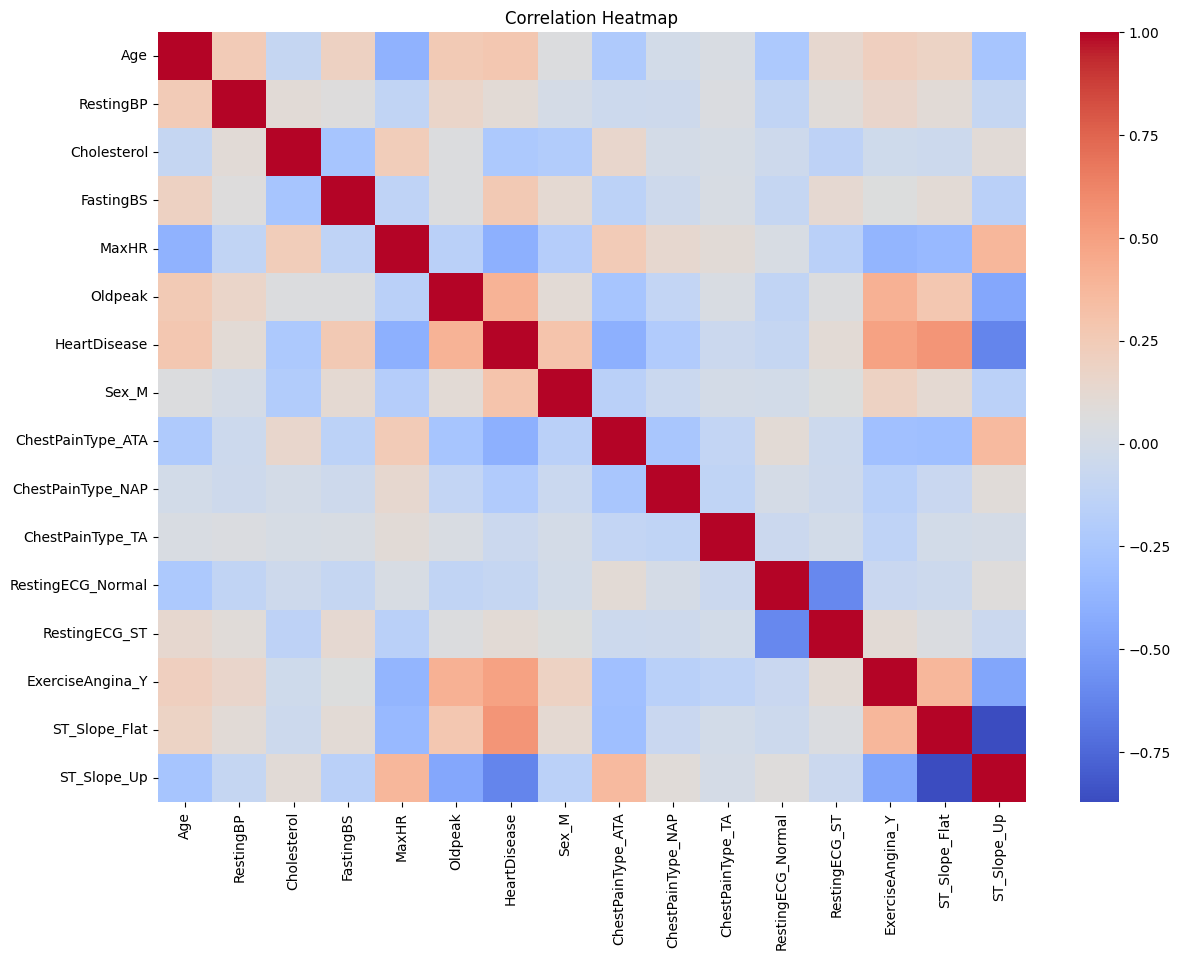

In [16]:
# Encode categorical data for correlation
encoded_dataset = pd.get_dummies(dataset, drop_first=True)

plt.figure(figsize=(14,10))
sns.heatmap(encoded_dataset.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [17]:
#This shows that most columns are moderately correlated with target, but 'fbs' is very weakly correlated.

## Exploratory Data Analysis (EDA)

### First, analysing the target variable:

HeartDisease
1    508
0    410
Name: count, dtype: int64


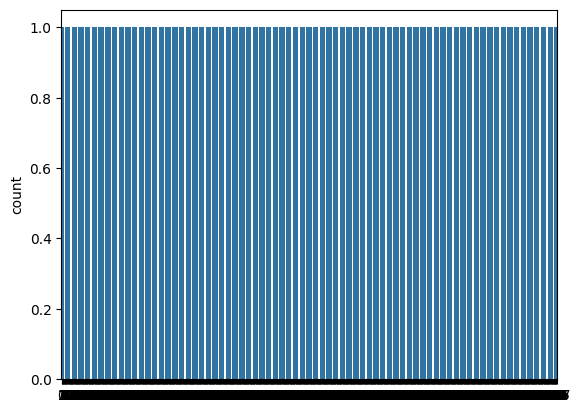

In [18]:
y = dataset["HeartDisease"]

sns.countplot(y)


target_temp = dataset.HeartDisease.value_counts()

print(target_temp)

In [19]:
print("Percentage of patience without heart problems: "+str(round(target_temp[0]*100/303,2)))
print("Percentage of patience with heart problems: "+str(round(target_temp[1]*100/303,2)))

#Alternatively,
# print("Percentage of patience with heart problems: "+str(y.where(y==1).count()*100/303))
# print("Percentage of patience with heart problems: "+str(y.where(y==0).count()*100/303))

# #Or,
# countNoDisease = len(df[df.target == 0])
# countHaveDisease = len(df[df.target == 1])

Percentage of patience without heart problems: 135.31
Percentage of patience with heart problems: 167.66


### We'll analyse 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca' and 'thal' features

### Analysing the 'Sex' feature

In [20]:
dataset["Sex"].unique()

array(['M', 'F'], dtype=object)

##### We notice, that as expected, the 'sex' feature has 2 unique features

<Axes: xlabel='Sex', ylabel='HeartDisease'>

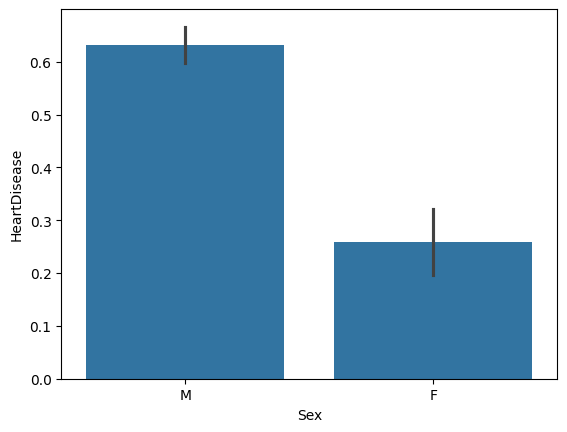

In [21]:
sns.barplot(x="Sex", y="HeartDisease", data=dataset)

##### We notice, that females are more likely to have heart problems than males

### Analysing the 'Chest Pain Type' feature

In [22]:
dataset["ChestPainType"].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

##### As expected, the CP feature has values from 0 to 3

<Axes: xlabel='ChestPainType', ylabel='HeartDisease'>

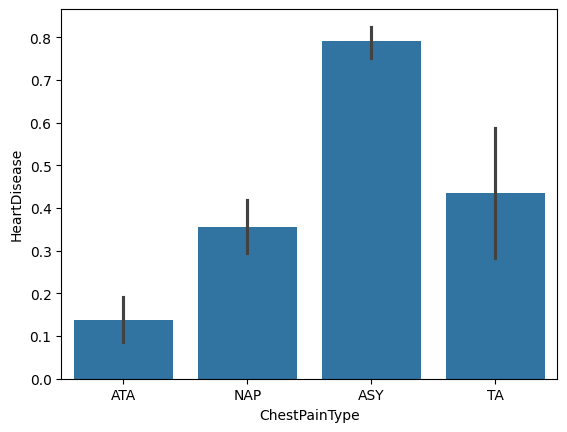

In [23]:
sns.barplot(x="ChestPainType", y="HeartDisease", data=dataset)

##### We notice, that chest pain of '0', i.e. the ones with typical angina are much less likely to have heart problems

### Analysing the FastingBS feature

In [24]:
dataset["FastingBS"].describe()

count    918.000000
mean       0.233115
std        0.423046
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: FastingBS, dtype: float64

In [25]:
dataset["FastingBS"].unique()

array([0, 1])

<Axes: xlabel='FastingBS', ylabel='HeartDisease'>

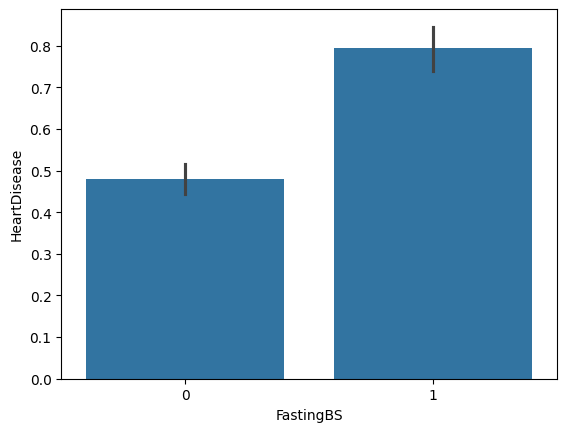

In [26]:
sns.barplot(x="FastingBS", y="HeartDisease", data=dataset)

##### Nothing extraordinary here

### Analysing the RestingECG feature

In [27]:
dataset["RestingECG"].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

<Axes: xlabel='RestingECG', ylabel='HeartDisease'>

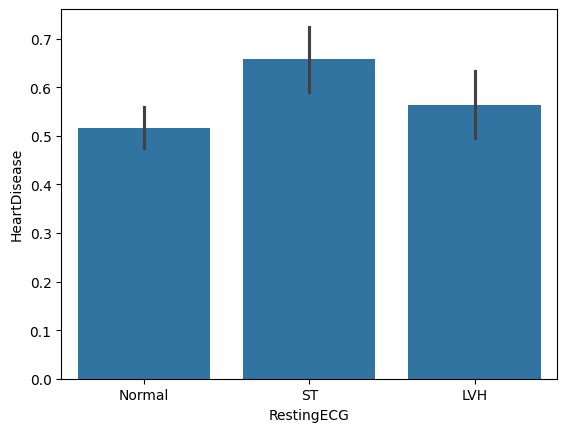

In [28]:
sns.barplot(x="RestingECG", y="HeartDisease", data=dataset)

##### We realize that people with restecg '1' and '0' are much more likely to have a heart disease than with restecg '2'

### Analysing the 'ExerciseAngina' feature

In [29]:
dataset["ExerciseAngina"].unique()

array(['N', 'Y'], dtype=object)

<Axes: xlabel='ExerciseAngina', ylabel='HeartDisease'>

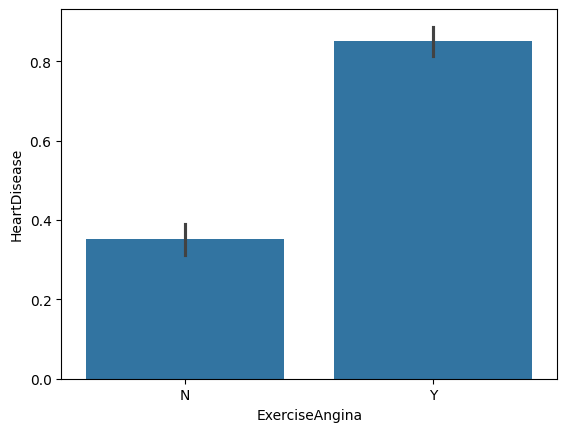

In [30]:
sns.barplot(x="ExerciseAngina", y="HeartDisease", data=dataset)

##### People with exang=1 i.e. Exercise induced angina are much less likely to have heart problems

### Analysing the ST_Slope feature

In [31]:
dataset["ST_Slope"].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

<Axes: xlabel='ST_Slope', ylabel='HeartDisease'>

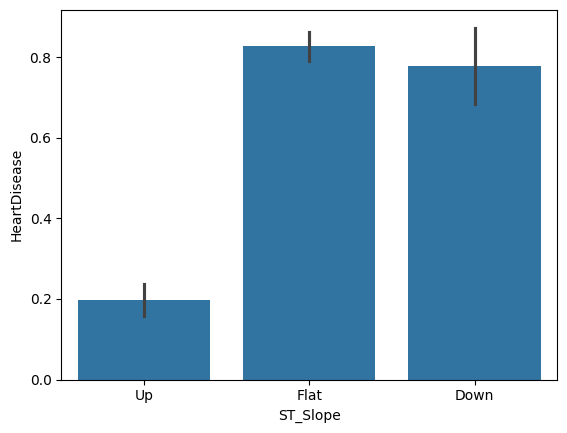

In [32]:
sns.barplot(x="ST_Slope", y="HeartDisease", data=dataset)

##### We observe, that Slope '2' causes heart pain much more than Slope '0' and '1'

In [33]:
X = dataset.drop("HeartDisease", axis=1)
y = dataset["HeartDisease"]

In [34]:
X = pd.get_dummies(X, drop_first=True)

## IV. Train Test split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
X_train.shape

(734, 15)

In [38]:
X_test.shape

(184, 15)

In [39]:
Y_train.shape

(734,)

In [40]:
Y_test.shape

(184,)

## V. Model Fitting

In [41]:
from sklearn.metrics import accuracy_score

### Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,Y_train)

Y_pred_lr = lr.predict(X_test)

In [46]:
Y_pred_lr.shape

(184,)

In [47]:
score_lr = round(accuracy_score(Y_pred_lr,Y_test)*100,2)

print("The accuracy score achieved using Logistic Regression is: "+str(score_lr)+" %")

The accuracy score achieved using Logistic Regression is: 85.33 %


### Naive Bayes

In [48]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train,Y_train)

Y_pred_nb = nb.predict(X_test)

In [49]:
Y_pred_nb.shape

(184,)

In [50]:
score_nb = round(accuracy_score(Y_pred_nb,Y_test)*100,2)

print("The accuracy score achieved using Naive Bayes is: "+str(score_nb)+" %")

The accuracy score achieved using Naive Bayes is: 85.87 %


### SVM

In [51]:
from sklearn import svm

sv = svm.SVC(kernel='linear')

sv.fit(X_train, Y_train)

Y_pred_svm = sv.predict(X_test)

In [52]:
Y_pred_svm.shape

(184,)

In [53]:
score_svm = round(accuracy_score(Y_pred_svm,Y_test)*100,2)

print("The accuracy score achieved using Linear SVM is: "+str(score_svm)+" %")

The accuracy score achieved using Linear SVM is: 85.33 %


### K Nearest Neighbors

In [54]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,Y_train)
Y_pred_knn=knn.predict(X_test)

In [55]:
Y_pred_knn.shape

(184,)

In [56]:
score_knn = round(accuracy_score(Y_pred_knn,Y_test)*100,2)

print("The accuracy score achieved using KNN is: "+str(score_knn)+" %")

The accuracy score achieved using KNN is: 66.3 %


### Decision Tree

In [57]:
from sklearn.tree import DecisionTreeClassifier

max_accuracy = 0


for x in range(200):
    dt = DecisionTreeClassifier(random_state=x)
    dt.fit(X_train,Y_train)
    Y_pred_dt = dt.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_dt,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x
        
#print(max_accuracy)
#print(best_x)


dt = DecisionTreeClassifier(random_state=best_x)
dt.fit(X_train,Y_train)
Y_pred_dt = dt.predict(X_test)

In [58]:
print(Y_pred_dt.shape)

(184,)


In [59]:
score_dt = round(accuracy_score(Y_pred_dt,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_dt)+" %")

The accuracy score achieved using Decision Tree is: 86.41 %


### Random Forest

In [61]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, Y_train)
Y_pred_rf = rf.predict(X_test)

score_rf = round(accuracy_score(Y_test, Y_pred_rf) * 100, 2)

print("The accuracy score achieved using Random Forest is:", score_rf, "%")

The accuracy score achieved using Random Forest is: 86.41 %


In [62]:
print(Y_pred_dt.shape)

(184,)


In [63]:
score_rf = round(accuracy_score(Y_test, Y_pred_rf) * 100, 2)

print("The accuracy score achieved using Random Forest is:", score_rf, "%")

The accuracy score achieved using Random Forest is: 86.41 %


### XGBoost

In [65]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, Y_train)

Y_pred_xgb = xgb_model.predict(X_test)

In [66]:
Y_pred_xgb.shape

(184,)

In [68]:
score_xgb = round(accuracy_score(Y_pred_xgb,Y_test)*100,2)

print("The accuracy score achieved using XGBoost is: "+str(score_xgb)+" %")

The accuracy score achieved using XGBoost is: 86.96 %


## VI. Output final score

In [76]:
scores = [score_lr,score_nb,score_svm,score_knn,score_dt,score_rf,score_xgb]
algorithms = ["Logistic Regression","Naive Bayes","Support Vector Machine","K-Nearest Neighbors","Decision Tree","Random Forest","XGBoost"]    

for i in range(len(algorithms)):
    print(
        "The accuracy score achieved using "
        + algorithms[i]
        + " is: "
        + str(scores[i])
        + " %"
    )

The accuracy score achieved using Logistic Regression is: 85.33 %
The accuracy score achieved using Naive Bayes is: 85.87 %
The accuracy score achieved using Support Vector Machine is: 85.33 %
The accuracy score achieved using K-Nearest Neighbors is: 66.3 %
The accuracy score achieved using Decision Tree is: 86.41 %
The accuracy score achieved using Random Forest is: 86.41 %
The accuracy score achieved using XGBoost is: 86.96 %


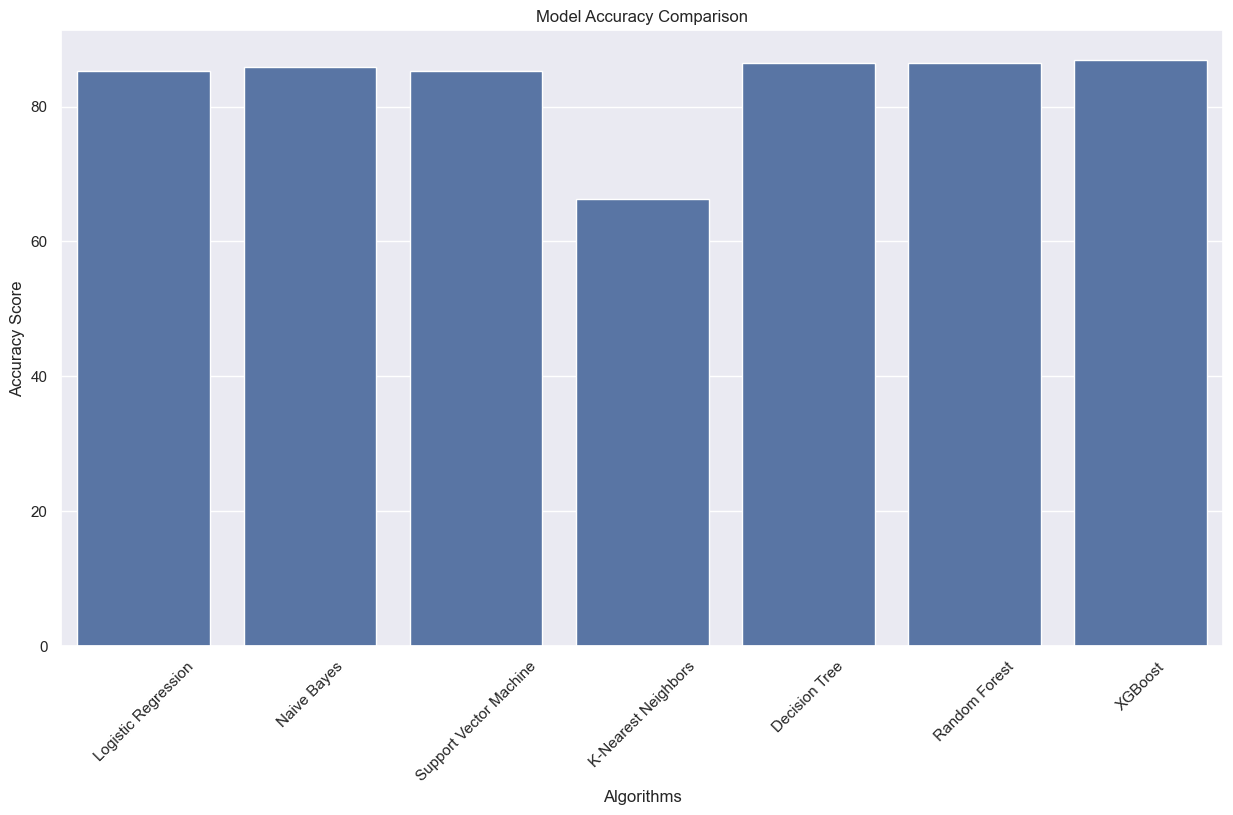

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Algorithms": algorithms,
    "Accuracy": scores
})

sns.set(rc={'figure.figsize': (15, 8)})
sns.barplot(x="Algorithms", y="Accuracy", data=results)
plt.xticks(rotation=45)
plt.xlabel("Algorithms")
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison")
plt.show()